# 1. Importing Required Libraries


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 2. Data Loading and Initial Preview

In [4]:
data = pd.read_csv("F:\\VS CODE\\Poultry_disease_ml\\poultry_disease_dataset_LARGE.csv")
df = pd.DataFrame(data)
df.head()

,Record_ID,Date,Farm_ID,Chicken_ID,Breed,Age_Days,Weight_kg,Body_Temperature_C,Feed_Intake_g_per_day,Water_Intake_ml_per_day,...,Flock_Size,Flock_Mortality_Rate_%,Egg_Production_Rate_%,Antibody_Titer_Level,Humidity_%,Ambient_Temperature_C,Ventilation_Level,Vaccination_Status,Feed_Type,Disease_Status
0,REC021155,2020-01-01,FARM_C,CH021155,Layer,26,1.36,41.4,117,271,...,1289,1.40,92,1.23,81,31,Good,Vaccinated,Grower,Healthy
1,REC036998,2020-01-01,FARM_D,CH036998,Broiler,33,2.07,41.8,129,232,...,1802,0.56,0,1.41,49,16,Good,Vaccinated,Starter,Healthy
2,REC021290,2020-01-01,FARM_A,CH021290,Layer,75,4.54,41.6,168,327,...,1391,0.11,92,0.90,81,32,Good,Vaccinated,Finisher,Healthy
3,REC028852,2020-01-01,FARM_B,CH028852,Broiler,136,6.06,44.8,132,304,...,330,83.86,0,0.11,84,35,Good,Vaccinated,Finisher,Avian_Influenza
4,REC003122,2020-01-01,FARM_A,CH003122,Dual_Purpose,114,5.48,41.1,179,304,...,1379,1.94,0,1.00,79,16,Good,Vaccinated,Starter,Healthy


# 3. Checking for Missing Values


In [5]:
df.isnull().sum()

Record_ID                   0
Date                        0
Farm_ID                     0
Chicken_ID                  0
Breed                       0
Age_Days                    0
Weight_kg                   0
Body_Temperature_C          0
Feed_Intake_g_per_day       0
Water_Intake_ml_per_day     0
Activity_Level              0
Respiratory_Rate_per_min    0
Droppings_Condition         0
Feather_Condition           0
Comb_Color                  0
Flock_Size                  0
Flock_Mortality_Rate_%      0
Egg_Production_Rate_%       0
Antibody_Titer_Level        0
Humidity_%                  0
Ambient_Temperature_C       0
Ventilation_Level           0
Vaccination_Status          0
Feed_Type                   0
Disease_Status              0
dtype: int64

# 4. Removing Irrelevant Columns


In [6]:
df.drop(columns=["Record_ID", "Date", "Farm_ID", "Chicken_ID"], inplace=True)

# 5. Dataset Structure and Data Types


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Breed                     50000 non-null  str    
 1   Age_Days                  50000 non-null  int64  
 2   Weight_kg                 50000 non-null  float64
 3   Body_Temperature_C        50000 non-null  float64
 4   Feed_Intake_g_per_day     50000 non-null  int64  
 5   Water_Intake_ml_per_day   50000 non-null  int64  
 6   Activity_Level            50000 non-null  str    
 7   Respiratory_Rate_per_min  50000 non-null  int64  
 8   Droppings_Condition       50000 non-null  str    
 9   Feather_Condition         50000 non-null  str    
 10  Comb_Color                50000 non-null  str    
 11  Flock_Size                50000 non-null  int64  
 12  Flock_Mortality_Rate_%    50000 non-null  float64
 13  Egg_Production_Rate_%     50000 non-null  int64  
 14  Antibody_Titer_Le

# 6. Statistical Summary of Numerical Features


In [8]:
df.describe()

,Age_Days,Weight_kg,Body_Temperature_C,Feed_Intake_g_per_day,Water_Intake_ml_per_day,Respiratory_Rate_per_min,Flock_Size,Flock_Mortality_Rate_%,Egg_Production_Rate_%,Antibody_Titer_Level,Humidity_%,Ambient_Temperature_C
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,74.976340,3.902886,41.981454,132.922480,302.198220,28.628900,1494.150660,8.761066,19.203560,0.879640,61.92466,25.974660
std,43.049489,2.186119,0.782112,41.154197,69.900123,10.894852,527.018341,15.530441,33.807713,0.382233,15.92619,6.631288
min,1.000000,0.300000,40.200000,20.000000,91.000000,15.000000,300.000000,0.000000,0.000000,0.100000,35.00000,15.000000
25%,38.000000,2.010000,41.400000,104.000000,252.000000,21.000000,1109.000000,0.830000,0.000000,0.520000,48.00000,20.000000
50%,75.000000,3.890000,41.700000,133.000000,302.000000,26.000000,1466.000000,1.660000,0.000000,0.920000,62.00000,26.000000
75%,112.000000,5.760000,42.400000,163.000000,354.000000,34.000000,1901.000000,10.100000,26.000000,1.210000,76.00000,32.000000
max,149.000000,9.240000,45.000000,260.000000,500.000000,67.000000,2499.000000,94.970000,94.000000,1.500000,89.00000,37.000000


# 7. Final Data Preview Before Preprocessing


In [9]:
df.head()

,Breed,Age_Days,Weight_kg,Body_Temperature_C,Feed_Intake_g_per_day,Water_Intake_ml_per_day,Activity_Level,Respiratory_Rate_per_min,Droppings_Condition,Feather_Condition,...,Flock_Size,Flock_Mortality_Rate_%,Egg_Production_Rate_%,Antibody_Titer_Level,Humidity_%,Ambient_Temperature_C,Ventilation_Level,Vaccination_Status,Feed_Type,Disease_Status
0,Layer,26,1.36,41.4,117,271,High,27,Normal,Good,...,1289,1.40,92,1.23,81,31,Good,Vaccinated,Grower,Healthy
1,Broiler,33,2.07,41.8,129,232,Medium,28,Normal,Good,...,1802,0.56,0,1.41,49,16,Good,Vaccinated,Starter,Healthy
2,Layer,75,4.54,41.6,168,327,High,22,Normal,Good,...,1391,0.11,92,0.90,81,32,Good,Vaccinated,Finisher,Healthy
3,Broiler,136,6.06,44.8,132,304,Very_Low,54,Abnormal,Poor,...,330,83.86,0,0.11,84,35,Good,Vaccinated,Finisher,Avian_Influenza
4,Dual_Purpose,114,5.48,41.1,179,304,High,24,Normal,Good,...,1379,1.94,0,1.00,79,16,Good,Vaccinated,Starter,Healthy


# 8. Disease Status Distribution by Breed


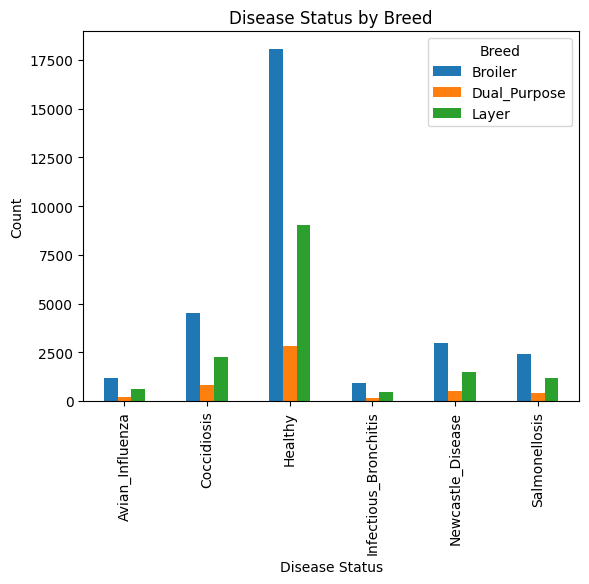

In [10]:
df["Breed"].groupby(df["Disease_Status"]).value_counts().unstack().plot(kind="bar")
plt.title("Disease Status by Breed")
plt.xlabel("Disease Status")
plt.ylabel("Count")
plt.legend(title="Breed")
plt.show()

# 9. Distribution of Poultry Breeds


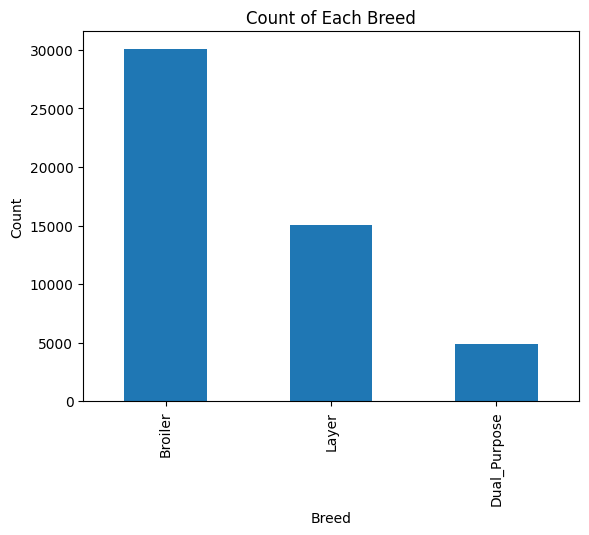

In [11]:
df["Breed"].value_counts().plot(kind="bar")
plt.title("Count of Each Breed")
plt.xlabel("Breed")
plt.ylabel("Count")
plt.show()

# 10. Vaccination Status Distribution by Breed


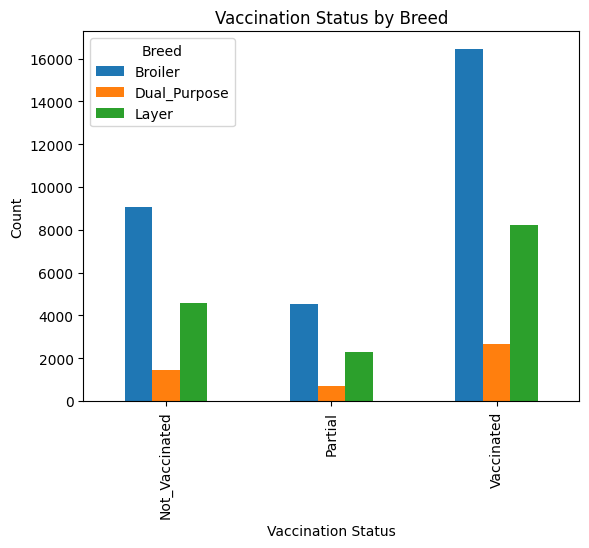

In [ ]:
df["Breed"].groupby(df["Vaccination_Status"]).value_counts().unstack().plot(kind="bar")
plt.title("Vaccination Status by Breed")
plt.xlabel("Vaccination Status")
plt.ylabel("Count")
plt.legend(title="Breed")
plt.show()

# 11. Separating Numerical and Categorical Features


In [13]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

C:\Users\mfati\AppData\Local\Temp\ipykernel_3512\2976791368.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


# 12. Numeric Feature Visualisation  by Target


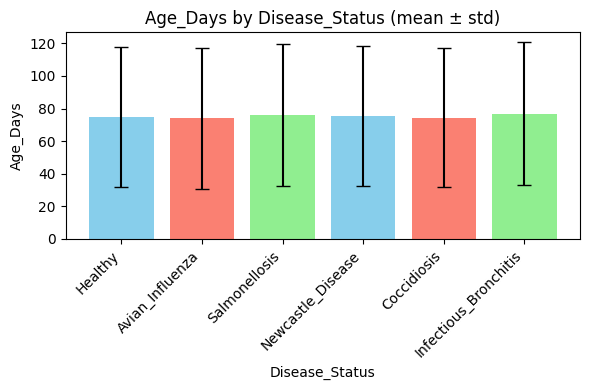

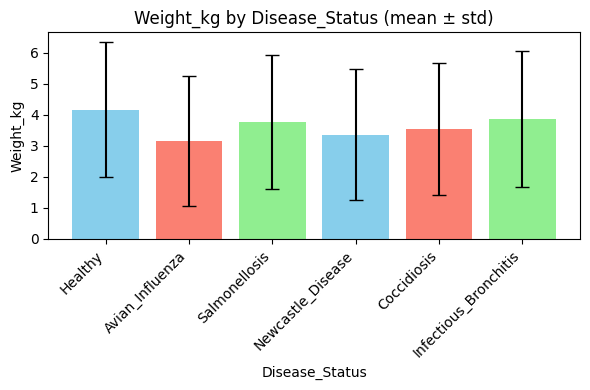

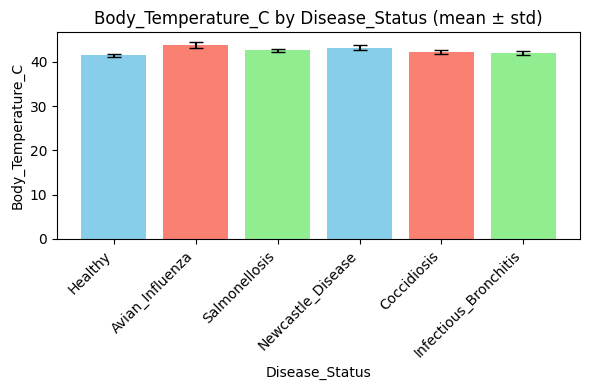

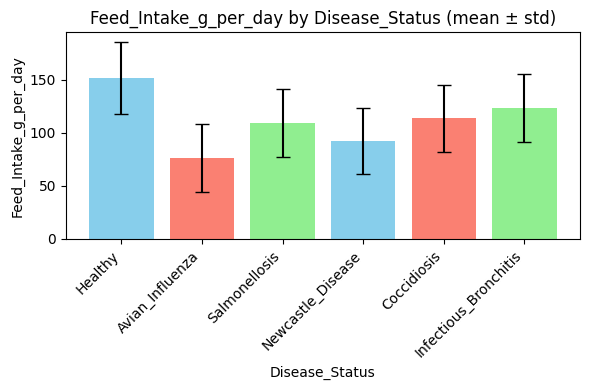

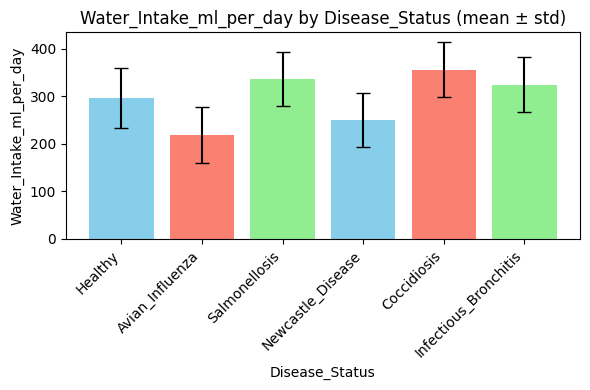

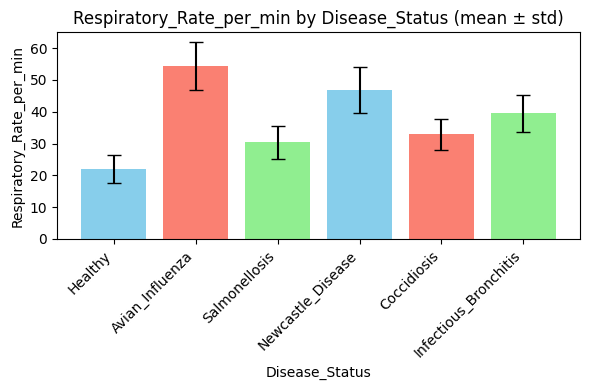

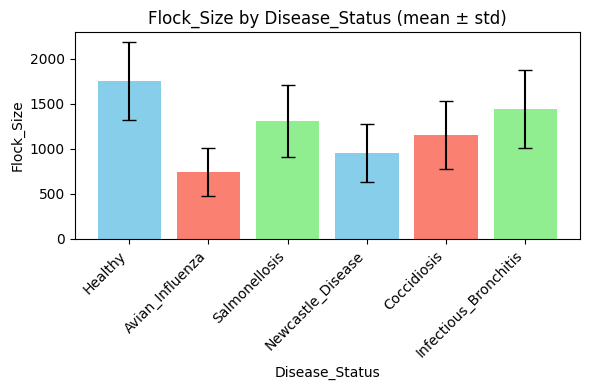

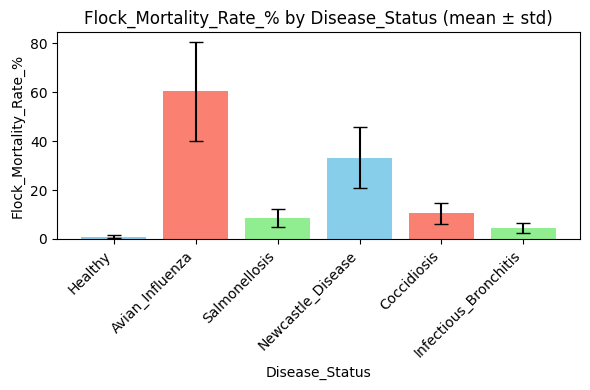

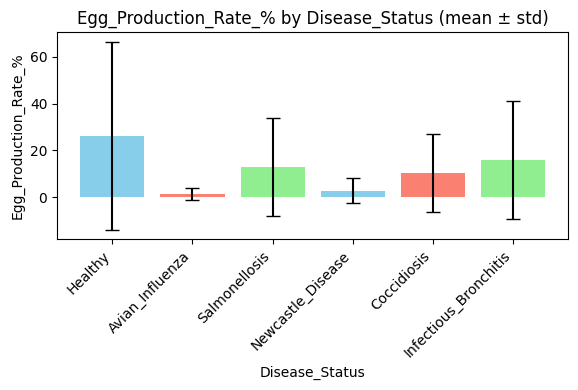

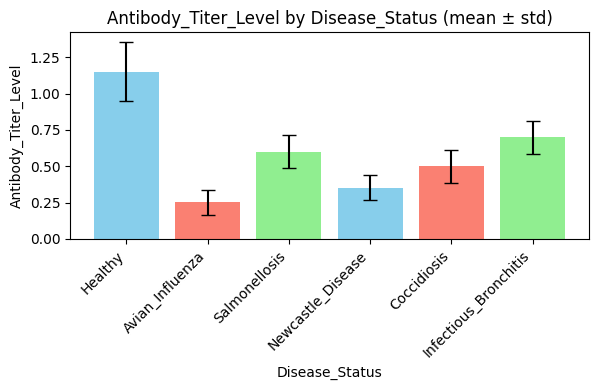

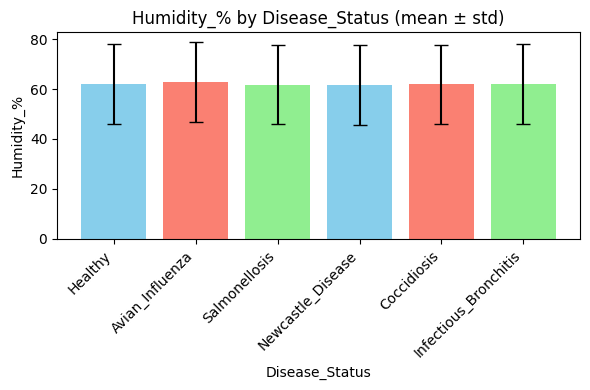

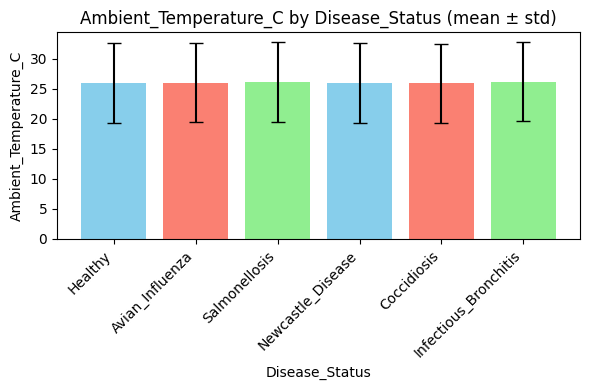

In [14]:
target_col = "Disease_Status"

for col in numeric_cols:
    plt.figure(figsize=(6, 4))

    classes = df[target_col].unique()
    means = [df[df[target_col] == c][col].mean() for c in classes]
    stds = [df[df[target_col] == c][col].std() for c in classes]

    x_pos = np.arange(len(classes))  # positions for bars

    plt.bar(
        x_pos,
        means,
        yerr=stds,
        capsize=5,
        color=["skyblue", "salmon", "lightgreen"][: len(classes)],
    )

    plt.title(f"{col} by {target_col} (mean ± std)")
    plt.ylabel(col)
    plt.xlabel(target_col)
    plt.xticks(x_pos, classes, rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# 13. Categorical Feature Visualisation by Target


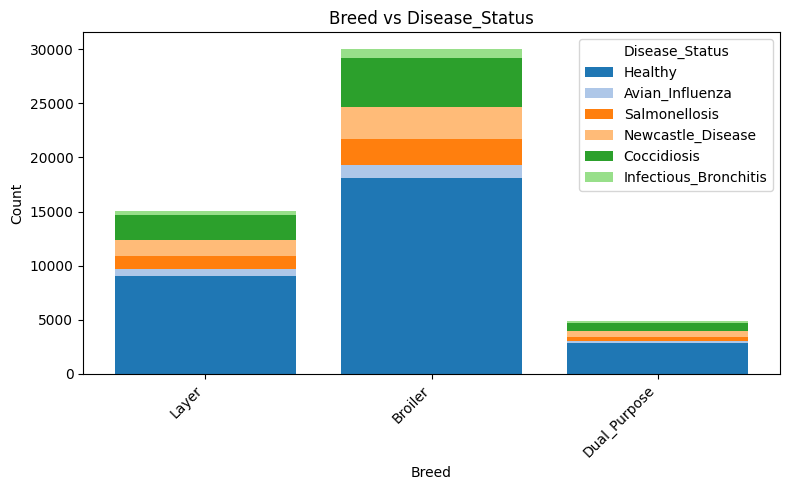

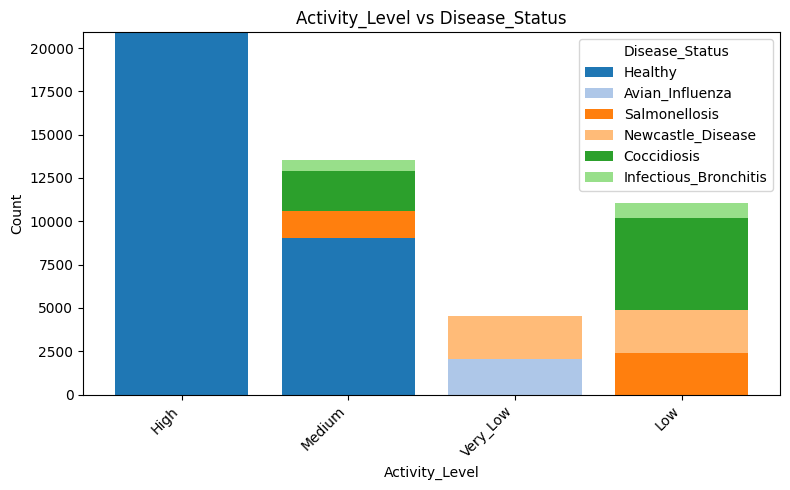

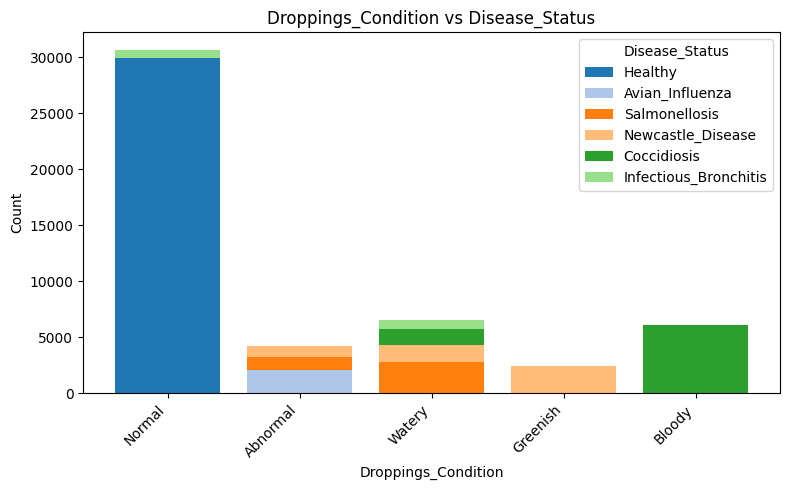

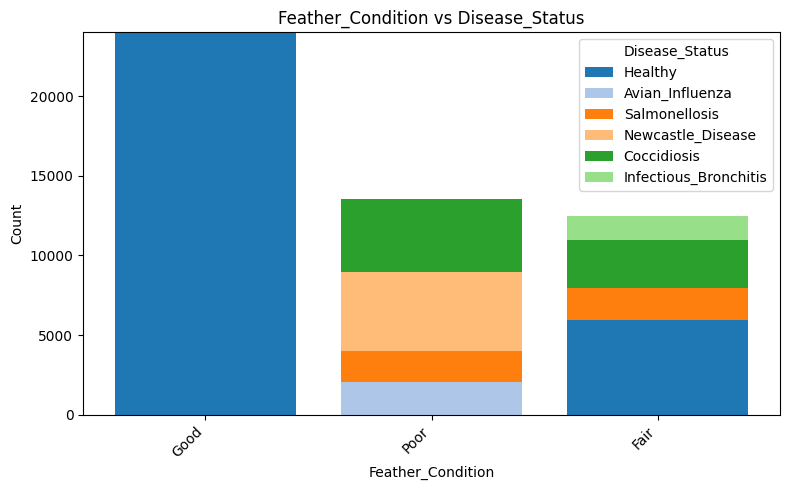

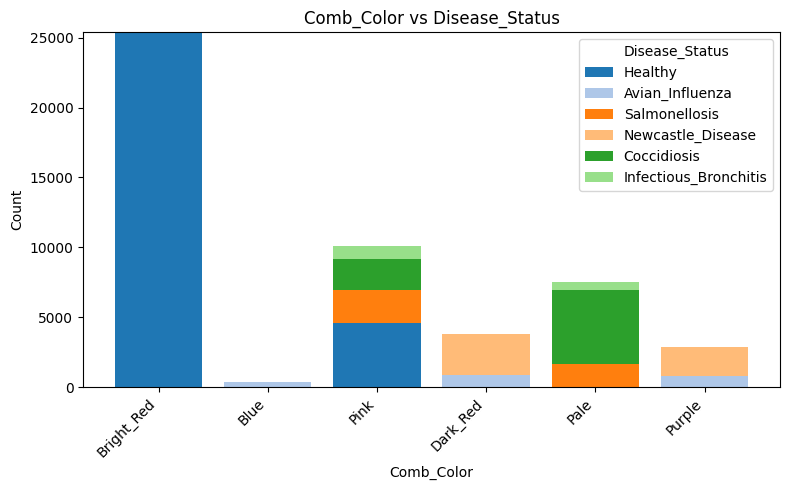

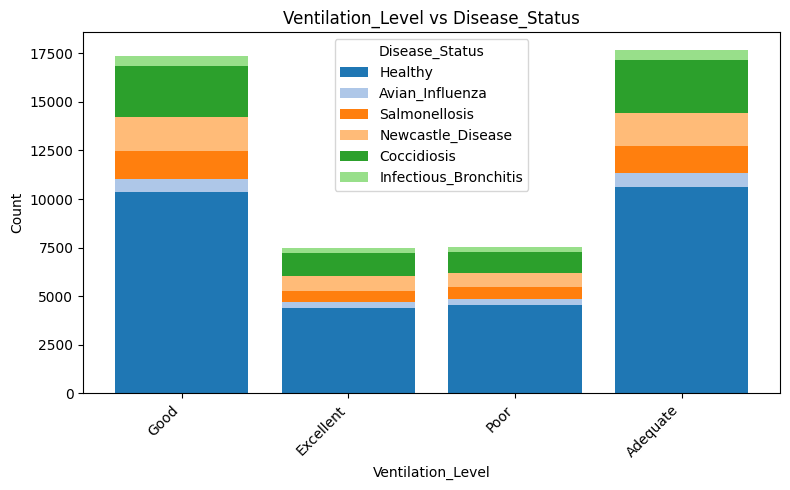

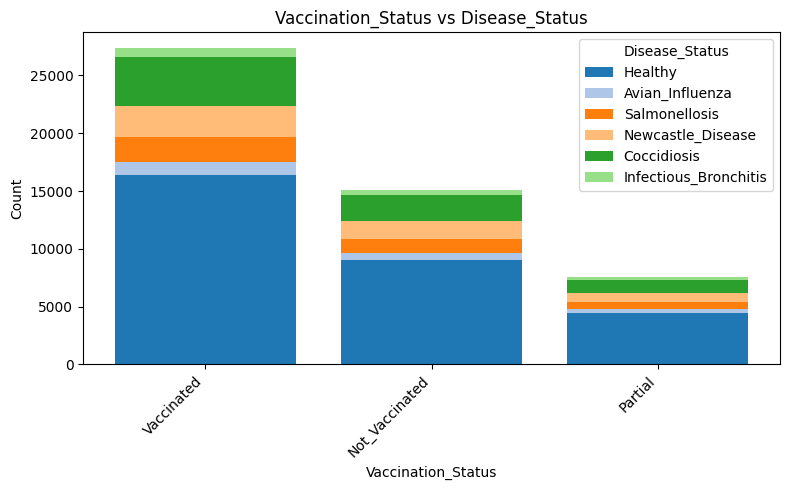

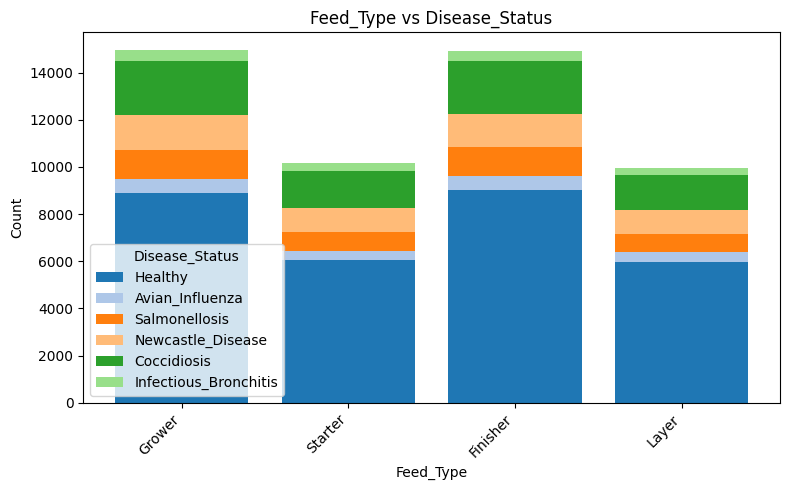

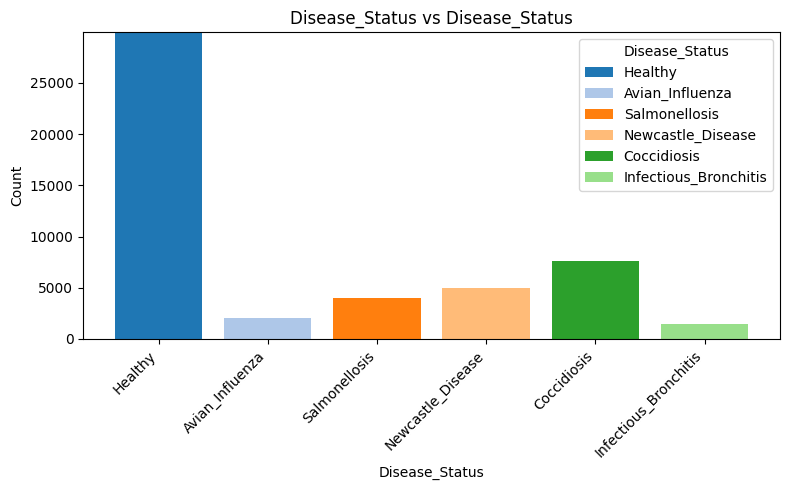

In [15]:
target_col = "Disease_Status"

for col in categorical_cols:
    plt.figure(figsize=(8, 5))

    categories = df[col].unique()
    classes = df[target_col].unique()

    # Generate colors automatically
    cmap = plt.get_cmap("tab20")  # supports up to 20 distinct classes
    colors = [cmap(i) for i in range(len(classes))]

    # Prepare counts per category and target class
    counts = []
    for cat in categories:
        cat_counts = (
            df[df[col] == cat][target_col].value_counts().reindex(classes, fill_value=0)
        )
        counts.append(cat_counts)
    counts = pd.DataFrame(counts, index=categories)

    # X positions
    x_pos = np.arange(len(categories))

    # Plot stacked bars
    bottom = np.zeros(len(categories))
    for i, cls in enumerate(classes):
        plt.bar(x_pos, counts[cls], bottom=bottom, color=colors[i], label=str(cls))
        bottom += counts[cls].values

    plt.title(f"{col} vs {target_col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(x_pos, categories, rotation=45, ha="right")
    plt.legend(title=target_col)
    plt.tight_layout()
    plt.show()

# 14. Feature Engineering


1️⃣ Ordered Categorical Encoding

In [16]:
X = df.copy()

vent_map = {"Poor": 1, "Adequate": 2, "Good": 3, "Excellent": 4}
activity_map = {"Very_Low": 1, "Low": 2, "Medium": 3, "High": 4}
droppings_map = {"Very_Low": 1, "Low": 2, "Medium": 3, "High": 4}
feather_map = {"Poor": 1, "Moderate": 2, "Good": 3, "Excellent": 4}
comb_map = {"Pale": 1, "Normal": 2, "Red": 3}

X["Ventilation_Numeric"] = X["Ventilation_Level"].map(vent_map)
X["Activity_Numeric"] = X["Activity_Level"].map(activity_map)
X["Droppings_Numeric"] = X["Droppings_Condition"].map(droppings_map)
X["Feather_Numeric"] = X["Feather_Condition"].map(feather_map)
X["Comb_Numeric"] = X["Comb_Color"].map(comb_map)

# Binary vaccination (safer)
X["Vaccinated_Binary"] = (X["Vaccination_Status"] == "Vaccinated").astype(int)

2️⃣ Environmental Features

In [17]:
X["Heat_Stress_Index"] = X["Ambient_Temperature_C"] * (X["Humidity_%"] / 100)

X["Temp_Deviation"] = abs(X["Body_Temperature_C"] - 41)

3️⃣ Resource & Growth Features

In [18]:
X["Stocking_Pressure"] = X["Flock_Size"] / (X["Ventilation_Numeric"] + 1)

X["Feed_per_kg"] = X["Feed_Intake_g_per_day"] / (X["Weight_kg"] + 1e-6)
X["Water_per_kg"] = X["Water_Intake_ml_per_day"] / (X["Weight_kg"] + 1e-6)

X["Resp_Activity_Ratio"] = X["Respiratory_Rate_per_min"] / (X["Activity_Numeric"] + 1)

X["Age_Weeks"] = X["Age_Days"] / 7
X["Is_Young"] = (X["Age_Weeks"] < 6).astype(int)

X["Weight_per_Day"] = X["Weight_kg"] / (X["Age_Days"] + 1)

4️⃣ Drop Risky / String Columns

In [19]:
X = X.drop(
    columns=[
        "Ventilation_Level",
        "Activity_Level",
        "Droppings_Condition",
        "Feather_Condition",
        "Comb_Color",
        "Egg_Production_Rate_%",
        "Flock_Mortality_Rate_%",
        "Vaccination_Status",
        "Antibody_Titer_Level",
    ]
)

# 15. Define Target and Features


In [20]:
y = X["Disease_Status"]
X = X.drop(columns=["Disease_Status"])

# 16. Train-Test Split


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=X["Breed"]
)

# 17. Define Categorical and Numerical Columns for Pipeline


In [22]:
categorical_cols = ["Breed", "Feed_Type"]  # nominal → one-hot
numeric_cols = X_train.columns.difference(categorical_cols)  # all other numeric

# 18. Preprocessing and Model Pipeline


1️⃣ Column Transformer

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

2️⃣ Pipeline

In [25]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(class_weight="balanced", random_state=42),
        ),
    ]
)

# 19. Train Random Forest Classifier


In [26]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

# 20. Model Evaluation on Test Set


In [27]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

                       precision    recall  f1-score   support

      Avian_Influenza       0.91      0.88      0.90       405
          Coccidiosis       0.82      0.93      0.88      1558
              Healthy       1.00      1.00      1.00      5902
Infectious_Bronchitis       0.90      0.78      0.84       304
    Newcastle_Disease       0.95      0.96      0.96       998
        Salmonellosis       0.83      0.66      0.73       833

             accuracy                           0.95     10000
            macro avg       0.90      0.87      0.88     10000
         weighted avg       0.95      0.95      0.94     10000

Accuracy: 0.9461


# 21. Visualizing Confusion Matrix


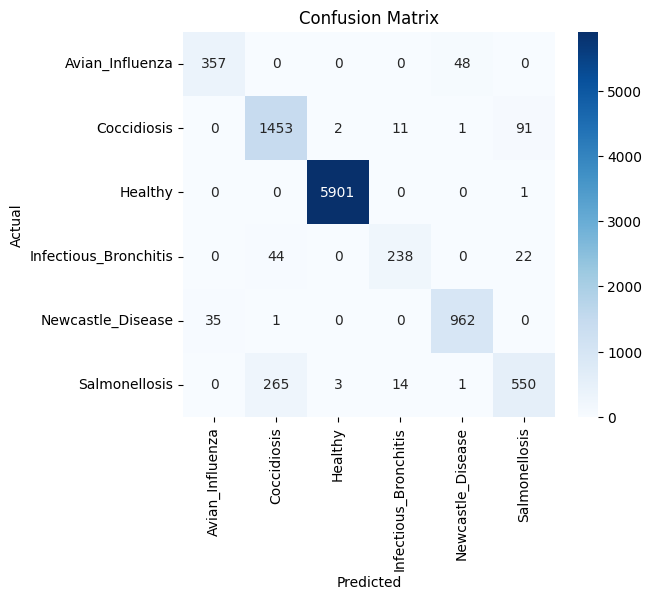

In [28]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=pipeline.classes_,
    yticklabels=pipeline.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 22. Hyperparameter Tuning with GridSearchCV


1️⃣ Define parameter grid for RandomForest

In [74]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],  # number of trees
    "classifier__max_depth": [None, 10, 20, 30],  # maximum depth of each tree
    "classifier__min_samples_split": [2, 5, 10],  # minimum samples to split node
    "classifier__min_samples_leaf": [1, 2, 4],  # minimum samples at leaf
    "classifier__max_features": ["sqrt", "log2", None],  # features considered per split
}

2️⃣ Use GridSearchCV with 5-fold CV

In [75]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",  # weighted F1 to handle imbalance
    n_jobs=-1,  # use all CPUs
    verbose=2,
)

3️⃣ Fit grid search

In [ ]:
grid_search.fit(X_train, y_train)

# 23. Evaluate Best Model from GridSearchCV


In [ ]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# 24. Generate Synthetic Samples and Predict Disease


1️⃣ Allowed categories

In [29]:
TRAIN_BREEDS = ["Broiler", "Layer", "Dual_Purpose"]
TRAIN_FEEDS = ["Grower", "Finisher", "Layer", "Starter"]

2️⃣ Ordinal mappings

In [30]:
vent_map = {"Poor": 1, "Adequate": 2, "Good": 3, "Excellent": 4}
activity_map = {"Very_Low": 1, "Low": 2, "Medium": 3, "High": 4}
droppings_map = {"Very_Low": 1, "Low": 2, "Medium": 3, "High": 4}
feather_map = {"Poor": 1, "Moderate": 2, "Good": 3, "Excellent": 4}
comb_map = {"Pale": 1, "Normal": 2, "Red": 3}

3️⃣ Function to generate a single sample

In [31]:
def generate_sample():
    age_days = np.random.randint(7, 180)
    weight_kg = round(np.random.uniform(0.5, 3.0), 2)
    body_temp_c = round(np.random.uniform(39.5, 42.0), 1)
    feed_intake_g = np.random.randint(50, 150)
    water_intake_ml = np.random.randint(80, 300)
    resp_rate = np.random.randint(20, 60)
    flock_size = np.random.randint(30, 200)
    humidity = np.random.randint(50, 80)
    ambient_temp = np.random.randint(28, 35)

    breed = np.random.choice(TRAIN_BREEDS)
    feed_type = np.random.choice(TRAIN_FEEDS)

    ventilation_level = np.random.choice(list(vent_map.keys()))
    activity_level = np.random.choice(list(activity_map.keys()))
    droppings_level = np.random.choice(list(droppings_map.keys()))
    feather_level = np.random.choice(list(feather_map.keys()))
    comb_level = np.random.choice(list(comb_map.keys()))
    vaccinated = np.random.choice([0, 1])

    # Compute numeric features
    ventilation_num = vent_map[ventilation_level]
    activity_num = activity_map[activity_level]
    droppings_num = droppings_map[droppings_level]
    feather_num = feather_map[feather_level]
    comb_num = comb_map[comb_level]
    vaccinated_bin = vaccinated

    heat_stress_index = ambient_temp * (humidity / 100)
    temp_deviation = abs(body_temp_c - 41)
    stocking_pressure = flock_size / (ventilation_num + 1e-6)
    feed_per_kg = feed_intake_g / (weight_kg + 1e-6)
    water_per_kg = water_intake_ml / (weight_kg + 1e-6)
    resp_activity_ratio = resp_rate / (activity_num + 1e-6)
    age_weeks = age_days / 7
    is_young = 1 if age_weeks < 6 else 0
    weight_per_day = weight_kg / (age_days + 1e-6)

    sample = {
        "Breed": breed,
        "Age_Days": age_days,
        "Weight_kg": weight_kg,
        "Body_Temperature_C": body_temp_c,
        "Feed_Intake_g_per_day": feed_intake_g,
        "Water_Intake_ml_per_day": water_intake_ml,
        "Respiratory_Rate_per_min": resp_rate,
        "Flock_Size": flock_size,
        "Humidity_%": humidity,
        "Ambient_Temperature_C": ambient_temp,
        "Feed_Type": feed_type,
        "Ventilation_Numeric": ventilation_num,
        "Activity_Numeric": activity_num,
        "Droppings_Numeric": droppings_num,
        "Feather_Numeric": feather_num,
        "Comb_Numeric": comb_num,
        "Vaccinated_Binary": vaccinated_bin,
        "Heat_Stress_Index": heat_stress_index,
        "Temp_Deviation": temp_deviation,
        "Stocking_Pressure": stocking_pressure,
        "Feed_per_kg": feed_per_kg,
        "Water_per_kg": water_per_kg,
        "Resp_Activity_Ratio": resp_activity_ratio,
        "Age_Weeks": age_weeks,
        "Is_Young": is_young,
        "Weight_per_Day": weight_per_day,
    }

    return sample

4️⃣ Generate 100 synthetic samples

In [32]:
samples_list = [generate_sample() for _ in range(100)]
input_df = pd.DataFrame(samples_list)

5️⃣ Predict diseases

In [33]:
predicted_diseases = pipeline.predict(input_df)

6️⃣ Display predictions

In [37]:
for i, pred in enumerate(predicted_diseases[:100]):
    print(f"Sample {i+1} Predicted Disease: {pred}")

Sample 1 Predicted Disease: Newcastle_Disease
Sample 2 Predicted Disease: Newcastle_Disease
Sample 3 Predicted Disease: Coccidiosis
Sample 4 Predicted Disease: Healthy
Sample 5 Predicted Disease: Avian_Influenza
Sample 6 Predicted Disease: Avian_Influenza
Sample 7 Predicted Disease: Newcastle_Disease
Sample 8 Predicted Disease: Avian_Influenza
Sample 9 Predicted Disease: Healthy
Sample 10 Predicted Disease: Healthy
Sample 11 Predicted Disease: Coccidiosis
Sample 12 Predicted Disease: Coccidiosis
Sample 13 Predicted Disease: Newcastle_Disease
Sample 14 Predicted Disease: Newcastle_Disease
Sample 15 Predicted Disease: Newcastle_Disease
Sample 16 Predicted Disease: Healthy
Sample 17 Predicted Disease: Newcastle_Disease
Sample 18 Predicted Disease: Newcastle_Disease
Sample 19 Predicted Disease: Newcastle_Disease
Sample 20 Predicted Disease: Newcastle_Disease
Sample 21 Predicted Disease: Newcastle_Disease
Sample 22 Predicted Disease: Newcastle_Disease
Sample 23 Predicted Disease: Healthy
Sa

In [38]:
X_train.columns

Index(['Breed', 'Age_Days', 'Weight_kg', 'Body_Temperature_C',
       'Feed_Intake_g_per_day', 'Water_Intake_ml_per_day',
       'Respiratory_Rate_per_min', 'Flock_Size', 'Humidity_%',
       'Ambient_Temperature_C', 'Feed_Type', 'Ventilation_Numeric',
       'Activity_Numeric', 'Droppings_Numeric', 'Feather_Numeric',
       'Comb_Numeric', 'Vaccinated_Binary', 'Heat_Stress_Index',
       'Temp_Deviation', 'Stocking_Pressure', 'Feed_per_kg', 'Water_per_kg',
       'Resp_Activity_Ratio', 'Age_Weeks', 'Is_Young', 'Weight_per_Day'],
      dtype='str')